# Non Hierarchical Clustering

## K-Means Clustering

### Distance Metric

1. Minkowski Distance <br>
$$d(x,y)=(\sum\limits_{i=1}^{n}|x_i-y_i|^p)^{\frac{1}{p}}$$
2. Euclidean Distance <br>
$$d(x,y)=\sqrt{\sum\limits_{i=1}^{n}(x_i-y_i)^2}$$
3. Manhattan Distance <br>
$$d(x,y)=\sum\limits_{i=1}^{n}|x_i-y_i|$$

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean_distance(x1,x2):
    return np.sqrt(np.sum((x1-x2)**2))

def k_means(X, k, max_iters=100, tol=1e-4):
    np.random.seed(42)
    centroids=X[np.random.choice(len(X), k, replace=False)]
    for _ in range(max_iters):
        clusters = {i: [] for i in range(k)}
        for x in X:
            distances=[euclidean_distance(x,centroid) for centroid in centroids] 
            cluster_idx=np.argmin(distances)
            clusters[cluster_idx].append(x)
        new_centroids=np.array([np.mean(clusters[i], axis=0) for i in range(k)])
        if np.linalg.norm(new_centroids-centroids)<tol:
            break
        centroids=new_centroids
    return clusters, centroids 

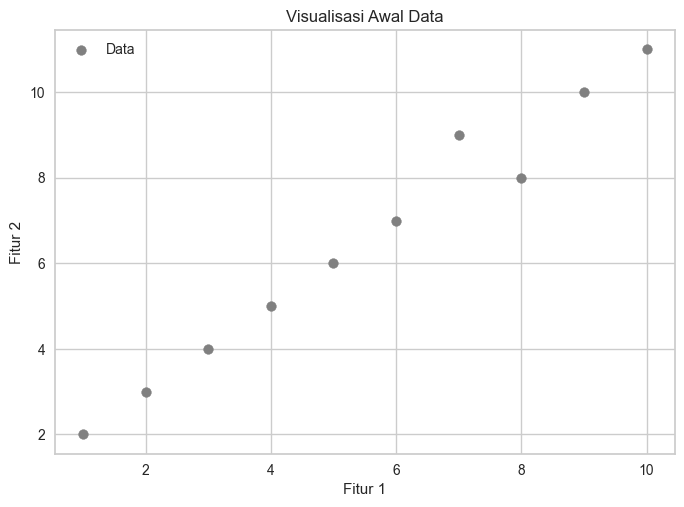

In [11]:
X=np.array([
    [2,3], [3,4], [5,6], [8,8], [9,10],
    [1,2], [4,5], [6,7], [7,9], [10,11]
])

plt.scatter(X[:,0], X[:,1], c='gray', marker='o', label='Data')
plt.title('Visualisasi Awal Data')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.show()

In [12]:
k=2
clusters, centroids = k_means(X,k)
print('Himpunan Cluster:')
for i, cluster in clusters.items():
    print(f'S_{i+1}:\n{np.array(cluster)}\n')
print('Himpunan Pusat Cluster Akhir:')
print(centroids)

Himpunan Cluster:
S_1:
[[ 8  8]
 [ 9 10]
 [ 6  7]
 [ 7  9]
 [10 11]]

S_2:
[[2 3]
 [3 4]
 [5 6]
 [1 2]
 [4 5]]

Himpunan Pusat Cluster Akhir:
[[8. 9.]
 [3. 4.]]


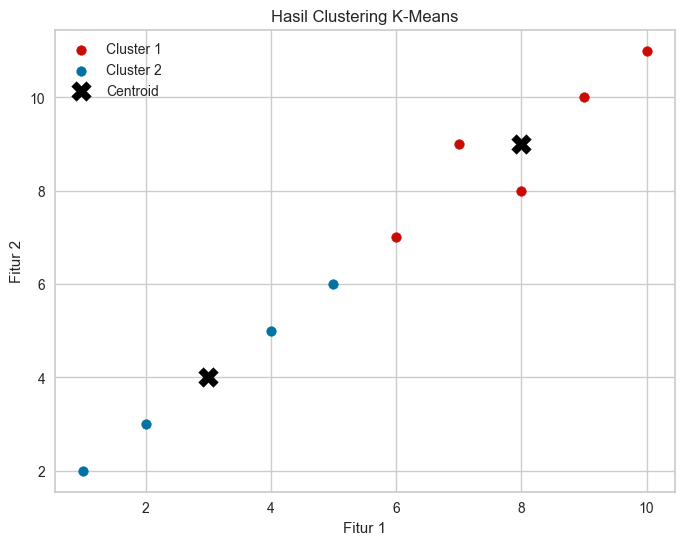

: 

In [ ]:
colors=['r', 'b', 'g', 'y', 'c']
plt.figure(figsize=(8,6))
for i, cluster in clusters.items():
    cluster_points=np.array(cluster)
    plt.scatter(cluster_points[:,0], cluster_points[:,1], c=colors[i], label=f'Cluster {i+1}')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200, label='Centroid')
plt.title('Hasil Clustering K-Means')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.show()

## Study Case K-Means

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [5]:
df=pd.read_csv('Data/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
X=df.iloc[:, [3,4]].values

print(pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)']))

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


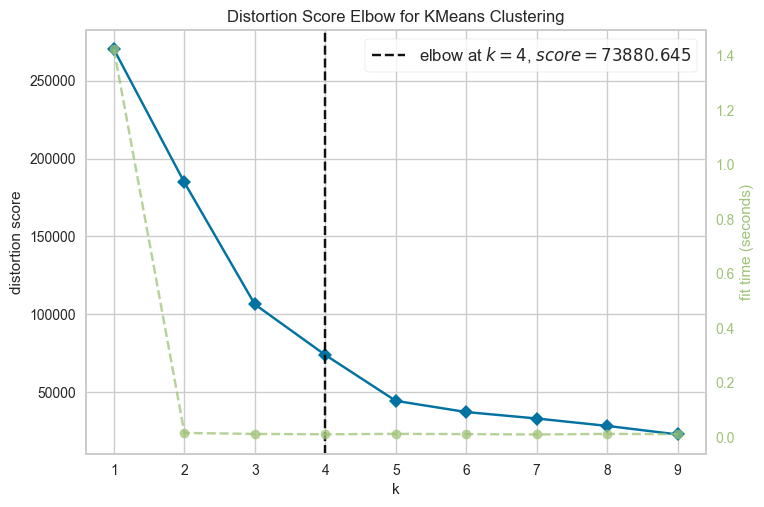

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
kmeans=KMeans()

visualizer=KElbowVisualizer(kmeans, k=(1,10))

visualizer.fit(X)

visualizer.show()

$SSE=\sum\limits_{i=1}^n (y_i-\hat{y}_i)^2$

In [54]:
kmeans=KMeans(n_clusters=4, random_state=0)
kmeans.fit(X)

labels=kmeans.labels_

k=4

def analyze_clusters(X, labels, k):
    print('Analisis Karakteristik Setiap Cluster:')
    for cluster_id in range(k):
        cluster_data=X[labels==cluster_id]
        
        mean_income=cluster_data[:,0].mean()
        mean_spending=cluster_data[:,1].mean()
        
        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata Annual Income (k$): {mean_income:.2f}")
        print(f"Rata-rata Spending Score (1-100): {mean_spending:.2f}")
        
analyze_clusters(X, labels, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata Annual Income (k$): 48.26
Rata-rata Spending Score (1-100): 56.48

Cluster 2:
Rata-rata Annual Income (k$): 86.54
Rata-rata Spending Score (1-100): 82.13

Cluster 3:
Rata-rata Annual Income (k$): 87.00
Rata-rata Spending Score (1-100): 18.63

Cluster 4:
Rata-rata Annual Income (k$): 26.30
Rata-rata Spending Score (1-100): 20.91


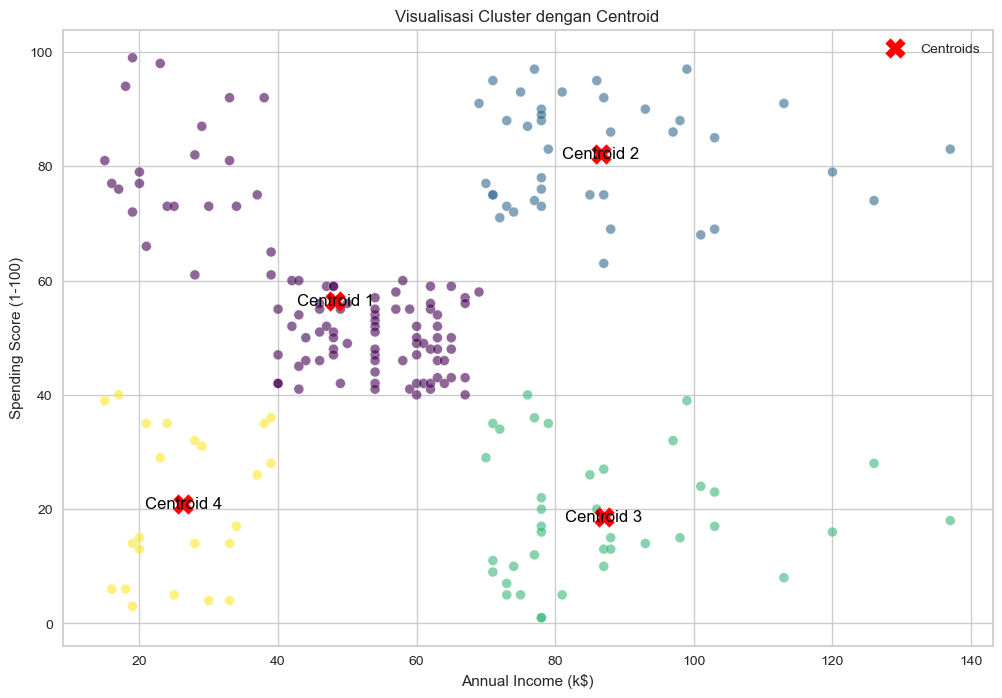

Nilai Centroids:
Centroid 1: Annual Income = 48.26, Spending Score = 56.48
Centroid 2: Annual Income = 86.54, Spending Score = 82.13
Centroid 3: Annual Income = 87.00, Spending Score = 18.63
Centroid 4: Annual Income = 26.30, Spending Score = 20.91


In [55]:
centroids = kmeans.cluster_centers_
 
# Visualisasi cluster
plt.figure(figsize=(12, 8))
 
# Plot data
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
 
# Plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
 
# Menambahkan label centroid pada plot
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='black', fontsize=12, ha='center', va='center')
 
# Menambahkan judul dan label
plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
 
plt.show()
 
# Menampilkan nilai centroid
print("Nilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: Annual Income = {centroid[0]:.2f}, Spending Score = {centroid[1]:.2f}")

In [56]:
sil_score = silhouette_score(X, labels)

print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.4932


In [63]:
kmeans=KMeans(n_clusters=5, random_state=0)
kmeans.fit(X)

labels=kmeans.labels_

k=5

def analyze_clusters(X, labels, k):
    print('Analisis Karakteristik Setiap Cluster:')
    for cluster_id in range(k):
        cluster_data=X[labels==cluster_id]
        
        mean_income=cluster_data[:,0].mean()
        mean_spending=cluster_data[:,1].mean()
        
        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata Annual Income (k$): {mean_income:.2f}")
        print(f"Rata-rata Spending Score (1-100): {mean_spending:.2f}")
        
analyze_clusters(X, labels, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata Annual Income (k$): 55.30
Rata-rata Spending Score (1-100): 49.52

Cluster 2:
Rata-rata Annual Income (k$): 86.54
Rata-rata Spending Score (1-100): 82.13

Cluster 3:
Rata-rata Annual Income (k$): 88.20
Rata-rata Spending Score (1-100): 17.11

Cluster 4:
Rata-rata Annual Income (k$): 26.30
Rata-rata Spending Score (1-100): 20.91

Cluster 5:
Rata-rata Annual Income (k$): 25.73
Rata-rata Spending Score (1-100): 79.36


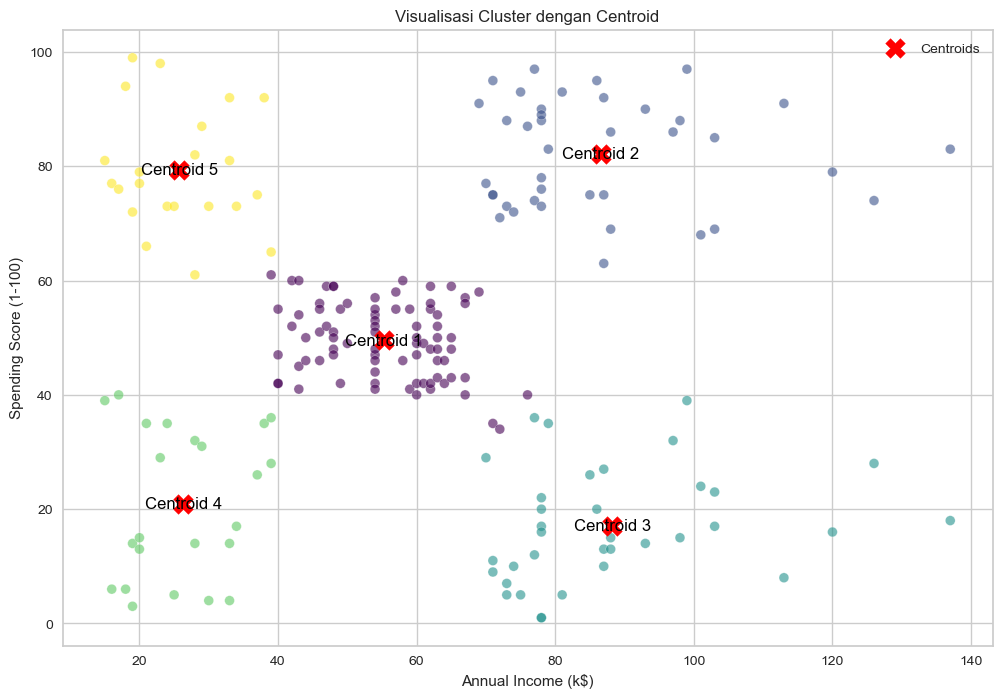

Nilai Centroids:
Centroid 1: Annual Income = 55.30, Spending Score = 49.52
Centroid 2: Annual Income = 86.54, Spending Score = 82.13
Centroid 3: Annual Income = 88.20, Spending Score = 17.11
Centroid 4: Annual Income = 26.30, Spending Score = 20.91
Centroid 5: Annual Income = 25.73, Spending Score = 79.36


In [64]:
centroids = kmeans.cluster_centers_
 
# Visualisasi cluster
plt.figure(figsize=(12, 8))
 
# Plot data
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
 
# Plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
 
# Menambahkan label centroid pada plot
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='black', fontsize=12, ha='center', va='center')
 
# Menambahkan judul dan label
plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
 
plt.show()
 
# Menampilkan nilai centroid
print("Nilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: Annual Income = {centroid[0]:.2f}, Spending Score = {centroid[1]:.2f}")

In [65]:
sil_score = silhouette_score(X, labels)

print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.5539
